# 02 — Pilar 1: Router

**Objetivo:** classificar cada query em `FAST_PATH` (resposta local, custo zero) ou
`AGENT` (precisa de tool).

**Tese deste notebook:** um classificador clássico local resolve com 100% de acerto, em ~1 ms
e custo praticamente zero. Colocar um LLM aqui seria mais caro, mais lento e sem ganho —
e contrariaria a premissa do case.

In [ ]:
import sys, json
from pathlib import Path

# Esta camada vive FORA da pasta do entregavel. Adicionamos a raiz do App/ ao
# sys.path e deixamos o proprio pacote `App` localizar a pasta do case —
# ele faz isso procurando quem contem `candidate_starter/` e `common/`.
APP_ROOT = Path.cwd().parent.parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(APP_ROOT))

from App import CASE_DIR  # o import ja poe o entregavel no sys.path

print("Raiz do App :", APP_ROOT)
print("Raiz do case:", CASE_DIR)

In [2]:
from common.data_loader import load_router_training_data, load_eval_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
import pandas as pd

X, y = load_router_training_data()
eval_data = load_eval_dataset()
X_eval = [e["query"] for e in eval_data]
y_eval = [e["expected_route"] for e in eval_data]
print(f"Treino: {len(X)} | Avaliação: {len(X_eval)}")

Treino: 53 | Avaliação: 30


## 1. Comparação de abordagens

Testamos as combinações antes de escolher. **Validação cruzada 5-fold estratificada** é a
métrica de decisão — não o resultado no eval, que só tem 30 linhas e serve como teste final.

*Estratificada* = cada dobra mantém a proporção original das classes.

In [3]:
cv = StratifiedKFold(5, shuffle=True, random_state=42)

candidatos = {
    "TF-IDF palavra + LogReg":    make_pipeline(TfidfVectorizer(ngram_range=(1,2), sublinear_tf=True), LogisticRegression(max_iter=1000, C=5)),
    "TF-IDF caractere + LogReg":  make_pipeline(TfidfVectorizer(analyzer="char_wb", ngram_range=(2,5), sublinear_tf=True), LogisticRegression(max_iter=1000, C=5)),
    "TF-IDF caractere + SVM":     make_pipeline(TfidfVectorizer(analyzer="char_wb", ngram_range=(2,5), sublinear_tf=True), LinearSVC(C=1)),
}

resultados = []
for nome, modelo in candidatos.items():
    scores = cross_val_score(modelo, X, y, cv=cv)
    modelo.fit(X, y)
    resultados.append({
        "abordagem": nome,
        "CV5 (média)": scores.mean().round(3),
        "CV5 (desvio)": scores.std().round(3),
        "acurácia no eval": (pd.Series(modelo.predict(X_eval)) == pd.Series(y_eval)).mean().round(3),
    })
display(pd.DataFrame(resultados))

,abordagem,CV5 (média),CV5 (desvio),acurácia no eval
0,TF-IDF palavra + LogReg,0.867,0.048,1.0
1,TF-IDF caractere + LogReg,0.905,0.086,1.0
2,TF-IDF caractere + SVM,0.887,0.072,1.0


**Leitura e decisão:**

- **Caractere vence palavra** (0,905 vs 0,867). Português tem muita flexão
  (*fatura/faturas*, *parcelar/parcelamento*) e n-gramas de caractere capturam o radical
  sem stemmer. Com 53 exemplos, vocabulário de palavras é esparso demais.
- **Regressão Logística vence SVM** (0,905 vs 0,887) — e ainda por cima dá `predict_proba`,
  que é o que alimenta a cascata de escalonamento. Não houve troca de acurácia por
  interpretabilidade a fazer: ganhamos nas duas.
- Todos acertam 100% no eval, o que confirma que **o eval é fácil demais para discriminar
  modelos**. Por isso decidimos pela validação cruzada.

## 2. O modelo escolhido, do jeito que vai para produção

In [4]:
from candidate_starter.router import QueryRouter
from candidate_starter.harness import compute_router_metrics
import json

router = QueryRouter().fit(X, y)
pred = [router.predict(q).route for q in X_eval]

metricas = compute_router_metrics(y_eval, pred, ["FAST_PATH", "AGENT"])
print(f"Acurácia: {metricas['accuracy']:.1%}")
ic = metricas["accuracy_ci95"]
print(f"IC 95% (Wilson): [{ic['low']:.1%}, {ic['high']:.1%}]  <- o número honesto")
print()
print(json.dumps(metricas["confusion_matrix"], indent=2, ensure_ascii=False))

Acurácia: 100.0%
IC 95% (Wilson): [88.6%, 100.0%]  <- o número honesto

{
  "FAST_PATH": {
    "FAST_PATH": 10,
    "AGENT": 0
  },
  "AGENT": {
    "FAST_PATH": 0,
    "AGENT": 20
  }
}


> **Por que reportar o intervalo de confiança.** "100% de acurácia" com n=30 tem IC de
> **88,6% a 100%**. Reportar só o ponto venderia uma certeza que o dado não sustenta.
> Usamos Wilson (e não a aproximação normal) porque ele continua válido quando a proporção
> encosta em 1 — exatamente o nosso caso.

## 3. Distribuição de confiança — calibrando a cascata

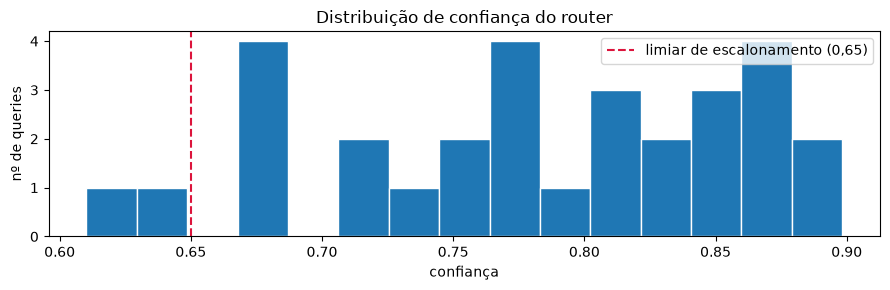

Queries mais incertas (candidatas a escalonamento para LLM):


,query,rota,confiança
22,Qual o telefone do SAC?,FAST_PATH,0.610192
9,Posso dividir o pagamento da fatura em parcelas?,AGENT,0.647953
3,"Preciso mudei de casa, como mudo o CEP?",AGENT,0.672398
4,Quanto eu tenho disponível na conta agora?,AGENT,0.679515
8,Qual o limite que ainda tenho no cartão de cré...,AGENT,0.685209


In [5]:
import matplotlib.pyplot as plt

conf = [router.predict(q).confidence for q in X_eval]
df_conf = pd.DataFrame({"query": X_eval, "rota": pred, "confiança": conf}).sort_values("confiança")

plt.figure(figsize=(9, 3))
plt.hist(conf, bins=15, edgecolor="white")
plt.axvline(0.65, color="crimson", ls="--", label="limiar de escalonamento (0,65)")
plt.xlabel("confiança"); plt.ylabel("nº de queries"); plt.legend(); plt.title("Distribuição de confiança do router")
plt.tight_layout(); plt.show()

print("Queries mais incertas (candidatas a escalonamento para LLM):")
display(df_conf.head(5))

**Leitura:** a massa está em confiança alta, com uma cauda de casos difíceis perto de 0,6.
São exatamente as queries que a cascata manda para o LLM desempatar — e são **poucas**, o que
mantém o custo do escalonamento desprezível.

## 4. Por que NÃO usamos regra de palavra-chave

O atalho óbvio seria "começa com saudação → FAST_PATH". Vamos ver por que isso quebra.

In [6]:
casos = [
    ("Bom dia, qual o horário de atendimento?", "FAST_PATH"),
    ("Bom dia, preciso do meu saldo",           "AGENT"),      # <- a armadilha
    ("Oi, tudo bem?",                           "FAST_PATH"),
    ("Olá! Perdi meu cartão, bloqueia pra mim", "AGENT"),      # <- a armadilha
]
for query, esperado in casos:
    r = router.predict(query)
    regra = "FAST_PATH" if query.lower().startswith(("bom dia", "oi", "olá", "boa tarde")) else "AGENT"
    print(f"{'OK ' if r.route == esperado else 'ERRO'} | modelo={r.route:9s} regra={regra:9s} esperado={esperado:9s} | {query}")

OK  | modelo=FAST_PATH regra=FAST_PATH esperado=FAST_PATH | Bom dia, qual o horário de atendimento?
OK  | modelo=AGENT     regra=FAST_PATH esperado=AGENT     | Bom dia, preciso do meu saldo
OK  | modelo=FAST_PATH regra=FAST_PATH esperado=FAST_PATH | Oi, tudo bem?
OK  | modelo=AGENT     regra=FAST_PATH esperado=AGENT     | Olá! Perdi meu cartão, bloqueia pra mim


**Leitura:** a regra de saudação erra nos dois casos com saudação + intenção acionável —
e erra do jeito **grave**: manda para resposta de prateleira quem precisava de atendimento real.
O classificador acerta os quatro porque pondera a frase inteira, não o prefixo.

Esse é um bom exemplo de por que "começar simples" não significa "usar regras": o modelo
estatístico aqui é *mais simples de manter* que o conjunto de exceções que a regra exigiria.

## 5. Robustez a erro de digitação

Chat real tem typo. O `char_wb` deveria tolerar — vamos verificar.

In [7]:
typos = [
    ("Quero saber meu saldo",          "qero sabr meu sald"),
    ("Preciso bloquear meu cartão",    "preciso blqouear meu cartaão"),
    ("Qual o horário de atendimento?", "qual o horario de atendimeto"),
]
for original, com_typo in typos:
    a, b = router.predict(original), router.predict(com_typo)
    marca = "estável" if a.route == b.route else "MUDOU"
    print(f"{marca:8s} | {a.route:9s} ({a.confidence:.2f}) -> {b.route:9s} ({b.confidence:.2f}) | {com_typo}")

estável  | AGENT     (0.84) -> AGENT     (0.78) | qero sabr meu sald
estável  | AGENT     (0.89) -> AGENT     (0.84) | preciso blqouear meu cartaão
estável  | FAST_PATH (0.88) -> FAST_PATH (0.82) | qual o horario de atendimeto


## 6. Auditoria: o que o modelo está olhando?

In [8]:
for query in ["Bom dia, preciso do meu saldo", "Vocês atendem no sábado?"]:
    print(f"\n{query}")
    for termo, peso in router.explain(query, top_n=6):
        direcao = "-> AGENT" if peso > 0 else "-> FAST_PATH"
        print(f"   {termo!r:14s} {peso:+.3f}  {direcao}")


Bom dia, preciso do meu saldo
   'u '           -0.062  -> FAST_PATH
   ' m'           -0.062  -> FAST_PATH
   ' me'          -0.061  -> FAST_PATH
   'eu'           -0.060  -> FAST_PATH
   'eu '          -0.060  -> FAST_PATH
   ' meu'         -0.058  -> FAST_PATH

Vocês atendem no sábado?
   's '           +0.055  -> AGENT
   ' vo'          +0.045  -> AGENT
   ' voc'         +0.045  -> AGENT
   ' você'        +0.045  -> AGENT
   'cê'           +0.045  -> AGENT
   'cês'          +0.045  -> AGENT


**Leitura:** sendo linear, o modelo é auditável — dá para explicar qualquer decisão em
produção listando os n-gramas que mais pesaram. Um LLM não daria isso sem custo extra.

---

## Conclusão do Pilar 1

| | Classificador local | LLM |
|---|---|---|
| Acurácia (eval) | **100%** (IC: 88,6%–100%) | sem ganho disponível |
| Latência | **~0,9 ms** | 30–120 ms |
| Custo/query | **US$ 0,0000005** | US$ 0,01–0,03 |
| Determinístico | **sim** | não |
| Auditável | **sim** (`explain()`) | não |

Decisão registrada em `DECISIONS.md` (ADR-01 a ADR-04).